In [45]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np

from collections import Counter


In [26]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Grayscale(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [27]:
full_train = datasets.ImageFolder(r"data\train", transform=transform)
test = datasets.ImageFolder(r"data\test", transform=transform)

In [28]:
train_size = int(0.9*len(full_train))
val_size = len(full_train) - train_size
train_data, val_data = random_split(full_train, [train_size, val_size])

In [29]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test, batch_size=64, shuffle=False)

In [34]:
class Fer_cnn(nn.Module):
    def __init__(self):
        super(Fer_cnn, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # 48 x 48
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2,2) # 24 x 24 
        
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2,2) # 12 x 12
        
        self.fc1 = nn.Linear(128*12*12, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 7)
        
        self.drop = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.bn1(self.conv1(x))
        x = F.relu(x)
        x = self.pool1(self.bn2(self.conv2(x)))
        x = F.relu(x)
        x = self.pool2(self.bn3(self.conv3(x)))
        x = F.relu(x)
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = self.fc3(x)
        
        return x

In [35]:
model = Fer_cnn()
print(model)

Fer_cnn(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=18432, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=7, bias=True)
  (drop): Dropout(p=0.5, inplace=False)
)


In [47]:
# Get labels from training dataset
all_labels = [label for _, label in train_data]

# Count class frequency
class_counts = Counter(all_labels)
print(class_counts)

Counter({3: 6476, 4: 4454, 5: 4332, 2: 3726, 0: 3597, 6: 2861, 1: 392})


In [48]:
num_classes = len(class_counts)
total_samples = sum(class_counts.values())

class_weights = []

for i in range(num_classes):
    weight = total_samples / (num_classes * class_counts[i])
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)

tensor([1.0262, 9.4162, 0.9906, 0.5700, 0.8287, 0.8521, 1.2902])


In [49]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr = 0.001)
num_epochs = 20
patience = 3
best_val_loss = float('inf')
counter = 0

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

In [37]:
for epoch in range(num_epochs):
    # training 
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images, labels
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # validation 
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images, labels
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc  = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # early stopping + saving best model 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        counter = 0
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% --> Best model saved!")
    else:
        counter += 1
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print("\nTraining complete!")

Epoch [1/20] - Train Loss: 1.8670, Train Acc: 23.81% | Val Loss: 1.7447, Val Acc: 27.97% --> Best model saved!
Epoch [2/20] - Train Loss: 1.7334, Train Acc: 29.47% | Val Loss: 1.6116, Val Acc: 34.94% --> Best model saved!
Epoch [3/20] - Train Loss: 1.6049, Train Acc: 36.26% | Val Loss: 1.5148, Val Acc: 44.27% --> Best model saved!
Epoch [4/20] - Train Loss: 1.5147, Train Acc: 40.48% | Val Loss: 1.4254, Val Acc: 45.52% --> Best model saved!
Epoch [5/20] - Train Loss: 1.4471, Train Acc: 43.65% | Val Loss: 1.3992, Val Acc: 47.89% --> Best model saved!
Epoch [6/20] - Train Loss: 1.3983, Train Acc: 45.56% | Val Loss: 1.3181, Val Acc: 50.78% --> Best model saved!
Epoch [7/20] - Train Loss: 1.3513, Train Acc: 47.92% | Val Loss: 1.3146, Val Acc: 49.32% --> Best model saved!
Epoch [8/20] - Train Loss: 1.3147, Train Acc: 49.23% | Val Loss: 1.2609, Val Acc: 53.64% --> Best model saved!
Epoch [9/20] - Train Loss: 1.2728, Train Acc: 50.37% | Val Loss: 1.2183, Val Acc: 54.68% --> Best model saved!
E

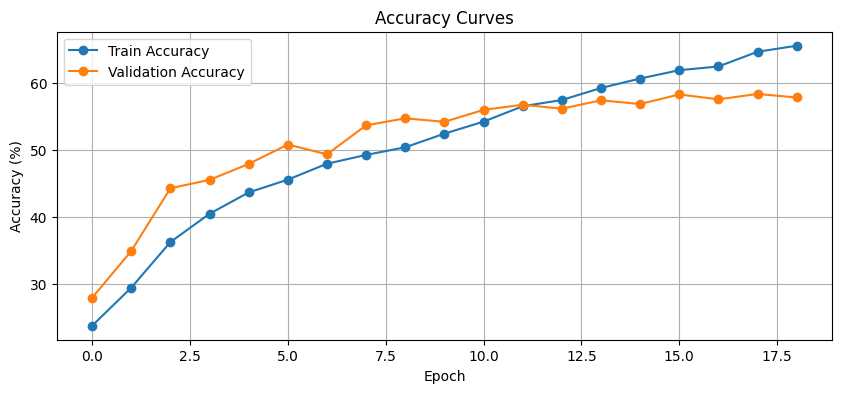

In [38]:
# accuracy curves
plt.figure(figsize=(10,4))
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

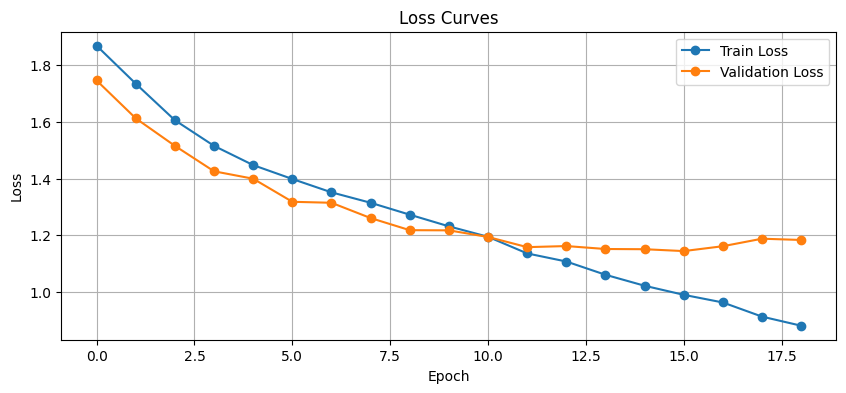

In [39]:
# loss curves
plt.figure(figsize=(10,4))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [40]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()  # set to evaluation mode

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images, labels
        outputs = model(images)
        _, preds = torch.max(outputs, 1)  
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


for i in range(10):  # print first 10 samples
    print(f"Predicted: {all_preds[i]}, Actual: {all_labels[i]}")

Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 4, Actual: 0
Predicted: 5, Actual: 0
Predicted: 0, Actual: 0
Predicted: 2, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 4, Actual: 0
Predicted: 0, Actual: 0


In [44]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

report = classification_report(all_labels, all_preds, digits=4)
print(report)

              precision    recall  f1-score   support

           0     0.4411    0.4301    0.4355       958
           1     0.0000    0.0000    0.0000       111
           2     0.4214    0.2695    0.3288      1024
           3     0.7889    0.7897    0.7893      1774
           4     0.5269    0.5166    0.5217      1233
           5     0.3698    0.5605    0.4456      1247
           6     0.7885    0.6775    0.7288       831

    accuracy                         0.5556      7178
   macro avg     0.4767    0.4634    0.4642      7178
weighted avg     0.5600    0.5556    0.5515      7178



c:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
